**Data Acquisition** and **Preprocessing**

#In this we'll acquire data from GSE47856 (GSE47856) and run quality control, extract metadata and feature data from it.

In [2]:
# import the important libraries
! pip install GEOparse

Defaulting to user installation because normal site-packages is not writeable
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)

   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   -------------------- ------------------- 1/2 [GEOparse]
   -------------------- ------------------- 1/2 [GEOparse]
   ---------------------------------------- 2/2 [GEOparse]




[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Import the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
import os
from sklearn.decomposition import PCA

In [44]:
# Make output directory


OUT = r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures"
PLOTS = os.path.join(OUT, "plots")
os.makedirs(PLOTS, exist_ok=True)

In [37]:
# Load the data
gse = GEOparse.get_GEO(
    filepath=r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Raw\GSE47856_family.soft.gz"
)

expr_frames, sample_meta = [], []
for gsm_name, gsm in gse.gsms.items():
    expr_frames.append(gsm.table.set_index("ID_REF")["VALUE"].rename(gsm_name))
    sample_meta.append({
        "gsm": gsm_name,
        "title": gsm.metadata.get("title", [""])[0],
        "characteristics": gsm.metadata.get("characteristics_ch1", []),
    })

expr = pd.concat(expr_frames, axis=1)             
pheno = pd.DataFrame(sample_meta).set_index("gsm")

11-Sep-2026 21:56:22 INFO GEOparse - Parsing C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Raw\GSE47856_family.soft.gz: 
11-Sep-2026 21:56:22 DEBUG GEOparse - DATABASE: GeoMiame
11-Sep-2026 21:56:22 DEBUG GEOparse - SERIES: GSE47856
11-Sep-2026 21:56:22 DEBUG GEOparse - PLATFORM: GPL6244
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160723
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160724
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160725
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160726
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160727
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160728
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160729
11-Sep-2026 21:56:25 DEBUG GEOparse - SAMPLE: GSM1160730
11-Sep-2026 21:56:26 DEBUG GEOparse - SAMPLE: GSM1160731
11-Sep-2026 21:56:26 DEBUG GEOparse - SAMPLE: GSM1160732
11-Sep-2026 21:56:26 DEBUG GEOparse - SAMPLE: GSM1160733
11-Sep-2026 21:56:26 DEBUG GEOparse - S

In [38]:
# Extract cell line (takes the letters/numbers before the '+' or '-')
pheno["cell_line"] = pheno["title"].str.extract(r"^([A-Za-z0-9]+)")

# Extract treatment: where '+' indicates cisplatin, '-' indicates control/sham according to the paper
pheno["treatment"] = np.where(
    pheno["title"].str.contains(r"\+"), 
    "cisplatin", 
    "control"
)
# Check the parsed result
print(pheno[["title", "cell_line", "treatment"]].head(10))

                 title cell_line  treatment
gsm                                        
GSM1160723   HeyA8-(1)     HeyA8    control
GSM1160724  HeyA8-(1)b     HeyA8    control
GSM1160725   HeyA8-(2)     HeyA8    control
GSM1160726  HeyA8-(2)b     HeyA8    control
GSM1160727   HeyA8-(3)     HeyA8    control
GSM1160728   HeyA8+(1)     HeyA8  cisplatin
GSM1160729   HeyA8+(3)     HeyA8  cisplatin
GSM1160730   HeyC2-(1)     HeyC2    control
GSM1160731   HeyC2-(2)     HeyC2    control
GSM1160732   HeyC2-(3)     HeyC2    control


In [39]:
# Extract both the metadata and the expression matrix
expr.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Output\01_expr.csv")
pheno.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Output\02_pheno.csv")

In [40]:
# Assigning probe IDs to gene symbols
gpl = gse.gpls[list(gse.gpls.keys())[0]]
probe2gene = gpl.table.set_index("ID")["gene_assignment"].str.extract(
    r"^[^/]*//\s*([A-Za-z0-9\-]+)\s*//"
)[0]
expr.index = expr.index.map(probe2gene)
expr = expr.dropna().groupby(level=0).mean()


In [41]:
# Saving the expression matrix
expr.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Output\03_expr_symbol.csv")

# Quality Check

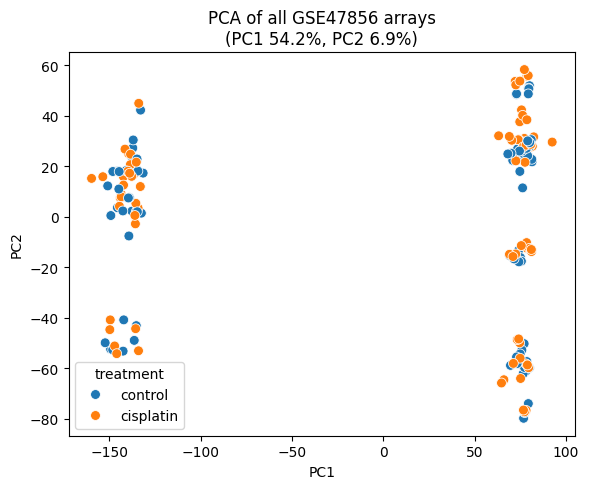

In [42]:
# QC plot 1: PCA of all samples
pca = PCA(n_components=2)
scores = pca.fit_transform(expr.T.fillna(0))
pca_df = pd.DataFrame(scores, columns=["PC1", "PC2"], index=expr.columns)
pca_df["treatment"] = pheno.loc[pca_df.index, "treatment"].values

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="treatment", s=50)
plt.title(f"PCA of all GSE47856 arrays\n(PC1 {pca.explained_variance_ratio_[0]:.1%}, "
          f"PC2 {pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, "01_PCA_by_treatment.png"), dpi=1000)

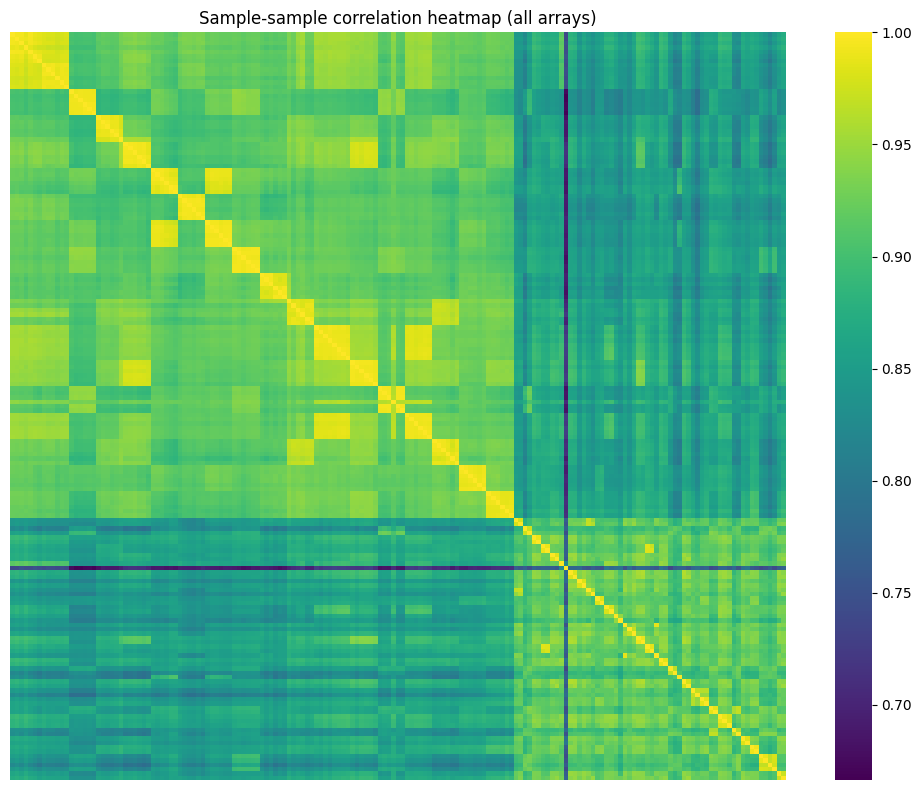

In [45]:
#  QC Plot 2: sample-sample correlation heatmap to check for outliers
corr = expr.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="viridis", xticklabels=False, yticklabels=False)
plt.title("Sample-sample correlation heatmap (all arrays)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, "02_sample_correlation_heatmap.png"), dpi=1000)


# Removing outliers

In [46]:
 # Find the sample with the lowest average correlation
low_corr_sample = corr.mean().idxmin()
print("Potential outlier array:", low_corr_sample)
print(pheno.loc[low_corr_sample])

Potential outlier array: GSM1160845
title                                                         Hey(+)
characteristics    [cell line: Hey, cell type: ovarian cancer cel...
cell_line                                                        Hey
treatment                                                  cisplatin
Name: GSM1160845, dtype: object


In [48]:
# Load the pheno data and expression matrix
pheno = pd.read_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Output\02_pheno.csv", index_col="gsm")
expr = pd.read_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Output\03_expr_symbol.csv", index_col=0)

In [49]:
# Remove the GSM1160845 column from expr
expr = expr.drop(columns="GSM1160845")

In [50]:
# export the cleaned expression matrix 
expr.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Output\04_expr_clean.csv")

In [51]:
# Remove the GSM1160845 column from pheno
pheno = pheno.drop(index="GSM1160845")
pheno.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Output\05_pheno_clean.csv")